
# Task B — Cyber Security Attack Dataset: EDA and Data-Quality Audit

This notebook performs a **structured exploratory data analysis (EDA)** and a **data-quality audit** for the **Cyber Security Attack** dataset.

## What this notebook includes
- one **dataset-overview table**
- one **class-distribution figure**
- one **missing-value summary** and **missingness visuals**
- one **feature-type summary**
- several **additional colorful visualizations** that reveal structure, risks, and potential modeling issues
- a final table called **EDA → pipeline implications**

The notebook is intentionally written in a **clean, report-ready style**: each task is stated before the code cell, plots use readable labels and captions, and short interpretations connect the findings to later preprocessing and modeling choices.


## Question / Task 1
**Import the required libraries, set plotting styles, and define a few helper utilities for a neat and colorful EDA workflow.**

In [1]:

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 100)

# Global plot style: more colorful than the previous version, but still clean.
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# A few reusable palettes for visual variety
palette_attack = sns.color_palette("Set2")
palette_quality = sns.color_palette("Spectral", 8)
palette_numeric = sns.color_palette("viridis", 6)
palette_categorical = sns.color_palette("tab10")


def pct(series):
    """Return percentage values rounded to two decimals."""
    return (series * 100).round(2)



## Question / Task 2
**Load the dataset, inspect the first rows, and confirm its basic shape.**

The loader below first checks the notebook folder and then `/mnt/data/` so the notebook remains easy to run after download.


In [2]:

candidate_paths = [
    Path("cybersecurity_attacks.csv"),
    Path("/mnt/data/cybersecurity_attacks.csv"),
]

csv_path = None
for path in candidate_paths:
    if path.exists():
        csv_path = path
        break

if csv_path is None:
    raise FileNotFoundError("Could not find 'cybersecurity_attacks.csv'. Place it next to the notebook or update the path.")

df = pd.read_csv(csv_path)
print(f"Loaded dataset from: {csv_path}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
display(df.head())


Loaded dataset from: /mnt/data/cybersecurity_attacks.csv
Shape: 40,000 rows × 25 columns


,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,Malware Indicators,Anomaly Scores,Alerts/Warnings,Attack Type,Attack Signature,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis iusto accusamus ad perferendis esse at. Asperiores ne...,IoC Detected,28.67,NaN,Malware,Known Pattern B,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT 6.2; Trident/5.0),Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omnis nulla dolore perspiciatis.\nIllo animi mollitia ...,IoC Detected,51.50,NaN,Malware,Known Pattern A,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT 6.0; Trident/4.0),Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectus quae nemo ea esse est rerum.,IoC Detected,87.42,Alert Triggered,DDoS,Known Pattern B,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT 6.2; Trident/5.0),Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro labore. Minima ab fugit officiis dicta perspiciatis...,NaN,15.79,Alert Triggered,Malware,Known Pattern B,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; rv:1.9.6.20) Gecko/2583-02-14 13:30:10 Firefox/11.0,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi voluptates soluta quis doloribus quas. Iure harum n...,NaN,0.52,Alert Triggered,DDoS,Known Pattern B,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT 6.2; Trident/3.0),Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall



## Question / Task 3
**Create a dataset-overview table with key structural information.**

This gives a compact first snapshot of scale, duplication, target setup, missingness, and numeric/categorical balance.


In [3]:

target_col = "Attack Type"

overview = pd.DataFrame({
    "Metric": [
        "Number of rows",
        "Number of columns",
        "Duplicate rows",
        "Duplicate rows (%)",
        "Target column",
        "Number of target classes",
        "Numeric columns",
        "Categorical/text columns",
        "Total missing values",
        "Columns with missing values"
    ],
    "Value": [
        len(df),
        df.shape[1],
        int(df.duplicated().sum()),
        round(df.duplicated().mean() * 100, 4),
        target_col if target_col in df.columns else "Not found",
        df[target_col].nunique(dropna=True) if target_col in df.columns else np.nan,
        df.select_dtypes(include=np.number).shape[1],
        df.select_dtypes(exclude=np.number).shape[1],
        int(df.isna().sum().sum()),
        int((df.isna().sum() > 0).sum())
    ]
})

display(overview)


,Metric,Value
0,Number of rows,40000
1,Number of columns,25
2,Duplicate rows,0
3,Duplicate rows (%),0.0
4,Target column,Attack Type
5,Number of target classes,3
6,Numeric columns,4
7,Categorical/text columns,21
8,Total missing values,99929
9,Columns with missing values,5



### Brief interpretation
- The overview table provides the **first audit checkpoint** before any modeling choices are made.
- It tells us whether de-duplication is needed, whether the task is **multiclass**, and whether missingness is local or widespread.
- A compact summary like this is useful in reports because it explains the dataset at a glance before showing more detailed plots.



## Question / Task 4
**Parse the timestamp, inspect feature types, and produce a feature-type summary table.**

The goal is to identify numeric, categorical, datetime, and high-cardinality fields that may need special handling later.


In [4]:

eda_df = df.copy()

# Parse timestamp if the column exists.
if "Timestamp" in eda_df.columns:
    eda_df["Timestamp"] = pd.to_datetime(eda_df["Timestamp"], errors="coerce")

feature_rows = []
for col in eda_df.columns:
    dtype_name = str(eda_df[col].dtype)
    non_null = eda_df[col].notna().sum()
    missing_pct = round(eda_df[col].isna().mean() * 100, 2)
    nunique = eda_df[col].nunique(dropna=True)
    uniqueness_ratio = round(nunique / len(eda_df), 4)

    if pd.api.types.is_datetime64_any_dtype(eda_df[col]):
        inferred_type = "datetime"
    elif pd.api.types.is_numeric_dtype(eda_df[col]):
        inferred_type = "numeric"
    else:
        inferred_type = "categorical/text"

    feature_rows.append({
        "Column": col,
        "dtype": dtype_name,
        "Inferred type": inferred_type,
        "Non-null": non_null,
        "Missing %": missing_pct,
        "Unique values": nunique,
        "Uniqueness ratio": uniqueness_ratio,
    })

feature_summary = pd.DataFrame(feature_rows).sort_values(["Inferred type", "Missing %", "Uniqueness ratio"], ascending=[True, False, False])
display(feature_summary)

feature_type_summary = (
    feature_summary.groupby("Inferred type")
    .agg(
        Number_of_columns=("Column", "count"),
        Avg_missing_pct=("Missing %", "mean"),
        Avg_uniqueness_ratio=("Uniqueness ratio", "mean")
    )
    .round(2)
    .reset_index()
)

print("\nFeature-type summary:")
display(feature_type_summary)


,Column,dtype,Inferred type,Non-null,Missing %,Unique values,Uniqueness ratio
12,Alerts/Warnings,object,categorical/text,19933,50.17,1,0.0000
23,IDS/IPS Alerts,object,categorical/text,19950,50.12,1,0.0000
10,Malware Indicators,object,categorical/text,20000,50.00,1,0.0000
22,Firewall Logs,object,categorical/text,20039,49.90,1,0.0000
21,Proxy Information,object,categorical/text,20149,49.63,20148,0.5037
1,Source IP Address,object,categorical/text,40000,0.00,40000,1.0000
2,Destination IP Address,object,categorical/text,40000,0.00,40000,1.0000
9,Payload Data,object,categorical/text,40000,0.00,40000,1.0000
17,User Information,object,categorical/text,40000,0.00,32389,0.8097
18,Device Information,object,categorical/text,40000,0.00,32104,0.8026



Feature-type summary:


,Inferred type,Number_of_columns,Avg_missing_pct,Avg_uniqueness_ratio
0,categorical/text,20,12.49,0.27
1,datetime,1,0.00,1.00
2,numeric,4,0.00,0.44



### Brief interpretation
- The feature-type summary helps decide **encoding**, **imputation**, and whether some columns behave more like identifiers than reusable predictive variables.
- Very high-cardinality text columns may be risky for naive one-hot encoding because they can create sparse features and poor generalization.
- Parsing the timestamp early also makes it possible to inspect temporal structure and consider time-aware splitting if needed.



## Question / Task 5
**Produce a missing-value summary table and create colorful missingness visualizations.**

This section highlights which variables may need imputation, removal, or special treatment during preprocessing.


In [5]:

missing_summary = (
    pd.DataFrame({
        "Column": eda_df.columns,
        "Missing count": eda_df.isna().sum().values,
        "Missing %": pct(eda_df.isna().mean()).values
    })
    .sort_values(["Missing %", "Missing count"], ascending=False)
    .reset_index(drop=True)
)

display(missing_summary)


,Column,Missing count,Missing %
0,Alerts/Warnings,20067,50.17
1,IDS/IPS Alerts,20050,50.12
2,Malware Indicators,20000,50.00
3,Firewall Logs,19961,49.90
4,Proxy Information,19851,49.63
5,Timestamp,0,0.00
6,Source IP Address,0,0.00
7,Destination IP Address,0,0.00
8,Source Port,0,0.00
9,Destination Port,0,0.00


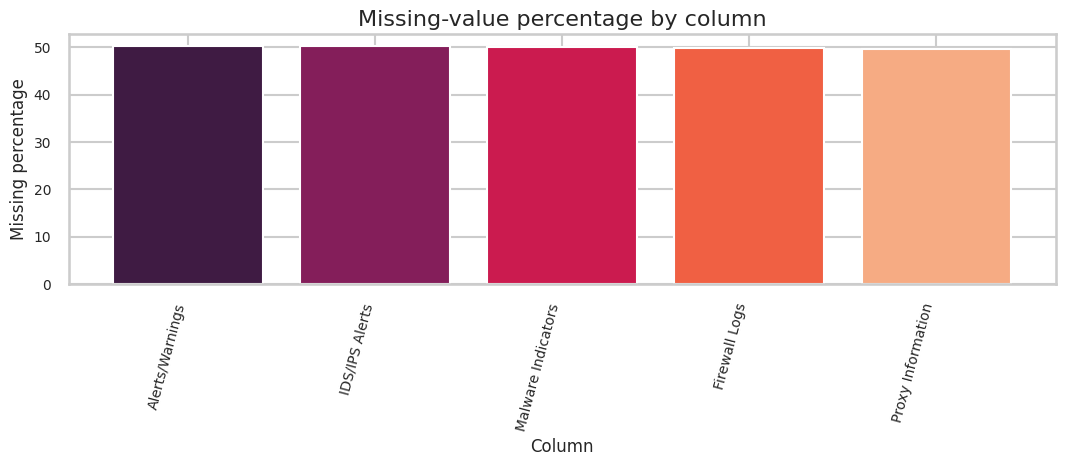

In [6]:
missing_plot_df = missing_summary[missing_summary["Missing count"] > 0].copy()

if not missing_plot_df.empty:
    colors = sns.color_palette("rocket", len(missing_plot_df))
    plt.figure(figsize=(11, 5))
    plt.bar(missing_plot_df["Column"], missing_plot_df["Missing %"], color=colors)
    plt.title("Missing-value percentage by column")
    plt.xlabel("Column")
    plt.ylabel("Missing percentage")
    plt.xticks(rotation=75, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset.")


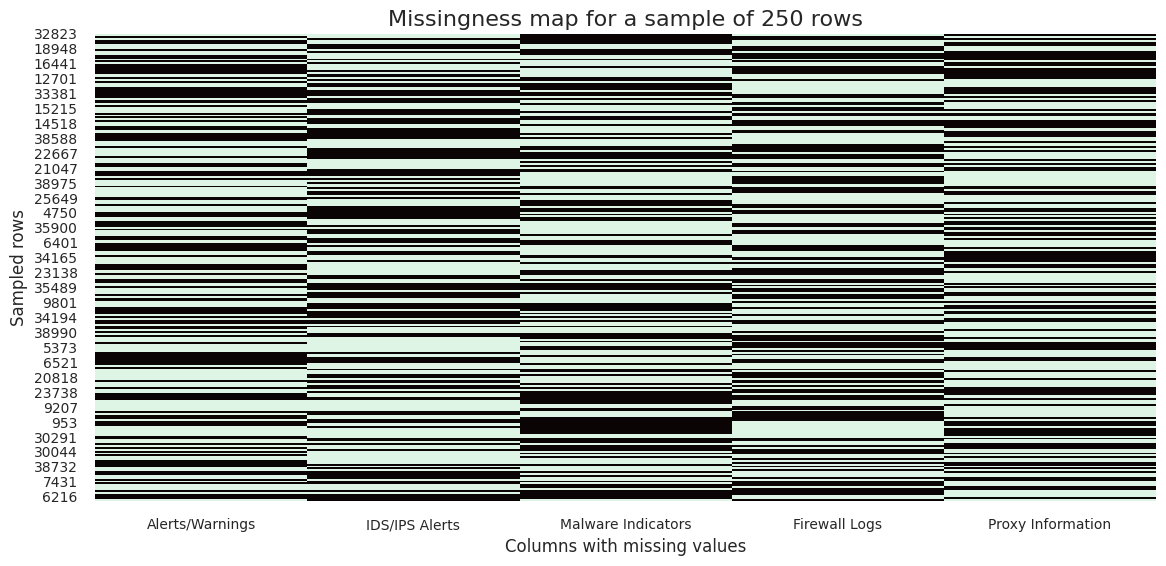

In [7]:

# Visualize the missingness pattern on a small row sample so the structure is easy to see.
missing_cols = missing_plot_df["Column"].tolist()

if missing_cols:
    sample_n = min(250, len(eda_df))
    sample_missing = eda_df[missing_cols].sample(sample_n, random_state=42)

    plt.figure(figsize=(12, 6))
    sns.heatmap(sample_missing.isna(), cbar=False, cmap="mako")
    plt.title(f"Missingness map for a sample of {sample_n} rows")
    plt.xlabel("Columns with missing values")
    plt.ylabel("Sampled rows")
    plt.tight_layout()
    plt.show()



### Brief interpretation
- Several columns have **substantial missingness**, which means they should not simply be ignored during preprocessing.
- The missingness map helps reveal whether values are missing in **blocks** or appear **randomly scattered**, which influences imputation strategy.
- In cybersecurity data, a missing log or alert field can sometimes be **informative**, so missing-value indicators may be worth testing as features.



## Question / Task 6
**Visualize the class distribution of the target variable.**

This is essential for checking class balance before choosing metrics, resampling strategies, or class weights.


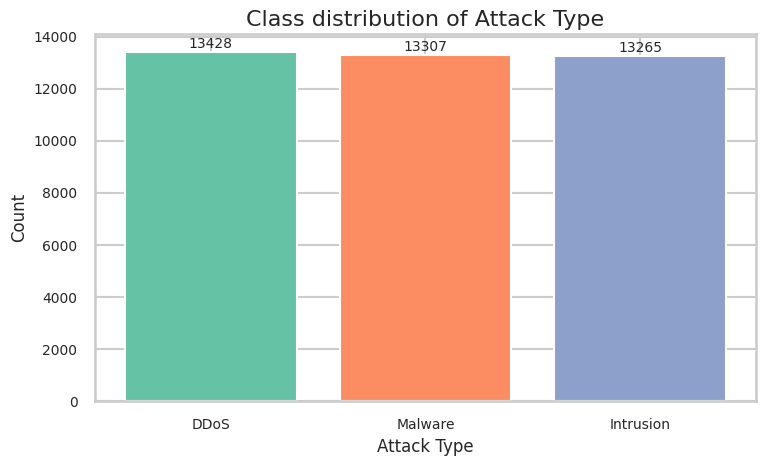

In [8]:
class_counts = eda_df[target_col].value_counts(dropna=False).reset_index()
class_counts.columns = [target_col, "Count"]

colors = sns.color_palette("Set2", len(class_counts))
plt.figure(figsize=(8, 5))
bars = plt.bar(class_counts[target_col], class_counts["Count"], color=colors)
plt.title("Class distribution of Attack Type")
plt.xlabel("Attack Type")
plt.ylabel("Count")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 30, f"{height:.0f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()



### Brief interpretation
- The target classes appear **roughly balanced**, which is helpful because it reduces the need for aggressive resampling in the first modeling iteration.
- Even with balanced classes, later evaluation should still include **precision**, **recall**, and **confusion matrices**, not just accuracy.



## Question / Task 7
**Explore whether attack classes differ by severity level.**

A row-normalized heatmap makes it easier to see whether the relationship between class and severity is strong or weak.


Severity Level,High,Low,Medium
Attack Type,,,
DDoS,33.68,33.14,33.18
Intrusion,33.37,32.97,33.65
Malware,33.31,32.76,33.94


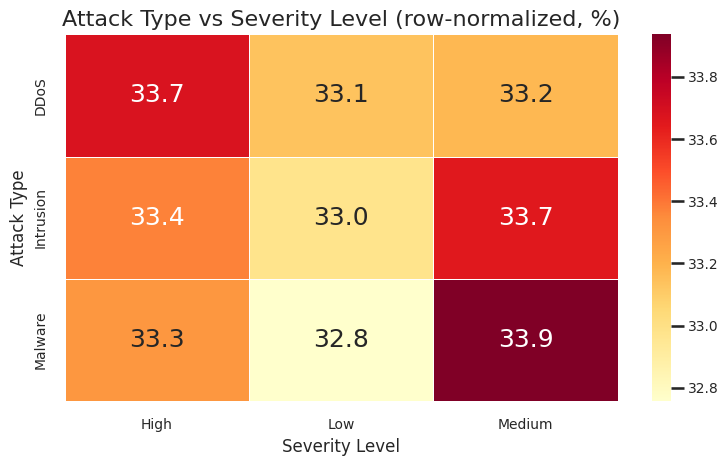

In [9]:

if {"Attack Type", "Severity Level"}.issubset(eda_df.columns):
    attack_severity = pd.crosstab(eda_df["Attack Type"], eda_df["Severity Level"], normalize="index") * 100
    display(attack_severity.round(2))

    plt.figure(figsize=(8, 5))
    sns.heatmap(attack_severity, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5)
    plt.title("Attack Type vs Severity Level (row-normalized, %)")
    plt.xlabel("Severity Level")
    plt.ylabel("Attack Type")
    plt.tight_layout()
    plt.show()
else:
    print("Required columns not found for this analysis.")



### Brief interpretation
- If the heatmap looks nearly uniform across rows, then **severity level alone** may not strongly separate the attack classes.
- This is useful because it prevents us from overestimating the predictive value of a single operational label.



## Question / Task 8
**Audit high-cardinality columns that may behave like identifiers or near-identifiers.**

These columns can create leakage risk, overfitting, or feature explosions if encoded naively.


In [10]:

uniqueness_df = pd.DataFrame({
    "Column": eda_df.columns,
    "Unique values": [eda_df[col].nunique(dropna=True) for col in eda_df.columns],
    "Uniqueness ratio": [eda_df[col].nunique(dropna=True) / len(eda_df) for col in eda_df.columns]
}).sort_values("Uniqueness ratio", ascending=False)

display(uniqueness_df.head(12).round(4))


,Column,Unique values,Uniqueness ratio
1,Source IP Address,40000,1.0000
2,Destination IP Address,40000,1.0000
9,Payload Data,40000,1.0000
0,Timestamp,39997,0.9999
17,User Information,32389,0.8097
18,Device Information,32104,0.8026
4,Destination Port,29895,0.7474
3,Source Port,29761,0.7440
21,Proxy Information,20148,0.5037
11,Anomaly Scores,9826,0.2456


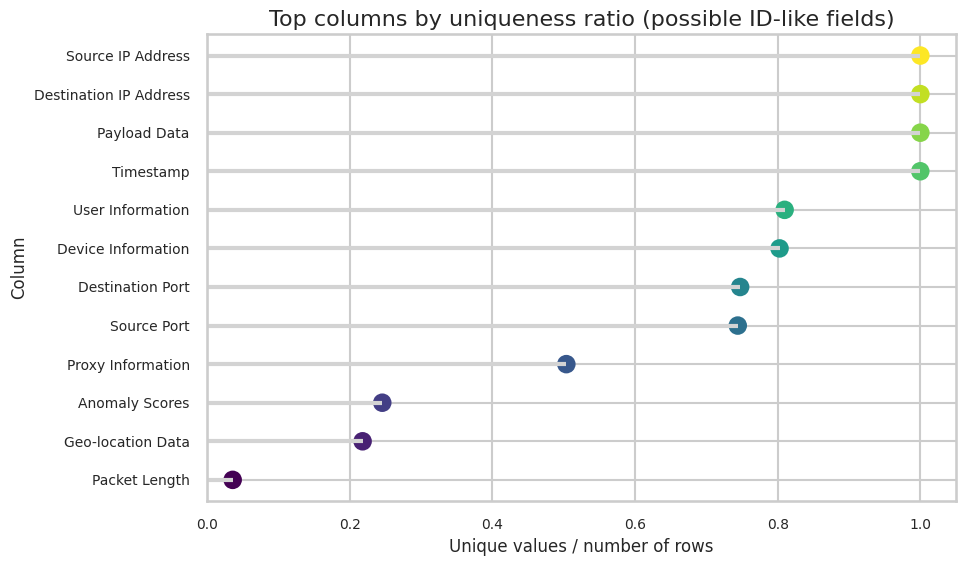

In [11]:

plot_uniqueness = uniqueness_df.head(12).iloc[::-1].copy()

plt.figure(figsize=(10, 6))
plt.hlines(y=plot_uniqueness["Column"], xmin=0, xmax=plot_uniqueness["Uniqueness ratio"], color="lightgray", linewidth=3)
plt.scatter(plot_uniqueness["Uniqueness ratio"], plot_uniqueness["Column"],
            s=140,
            c=np.linspace(0, 1, len(plot_uniqueness)),
            cmap="viridis")
plt.title("Top columns by uniqueness ratio (possible ID-like fields)")
plt.xlabel("Unique values / number of rows")
plt.ylabel("Column")
plt.xlim(0, 1.05)
plt.tight_layout()
plt.show()



### Brief interpretation
- Columns with a uniqueness ratio close to **1.0** are often poor candidates for direct one-hot encoding.
- IP addresses, user strings, payloads, and device descriptors may need **hashing**, **aggregation**, **embedding**, or even removal, depending on the task.



## Question / Task 9
**Visualize the numeric features to inspect spread, skew, and outliers.**

Numeric distributions can reveal scale differences, truncation, suspicious uniformity, or outlier behavior.


Numeric columns: ['Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores']


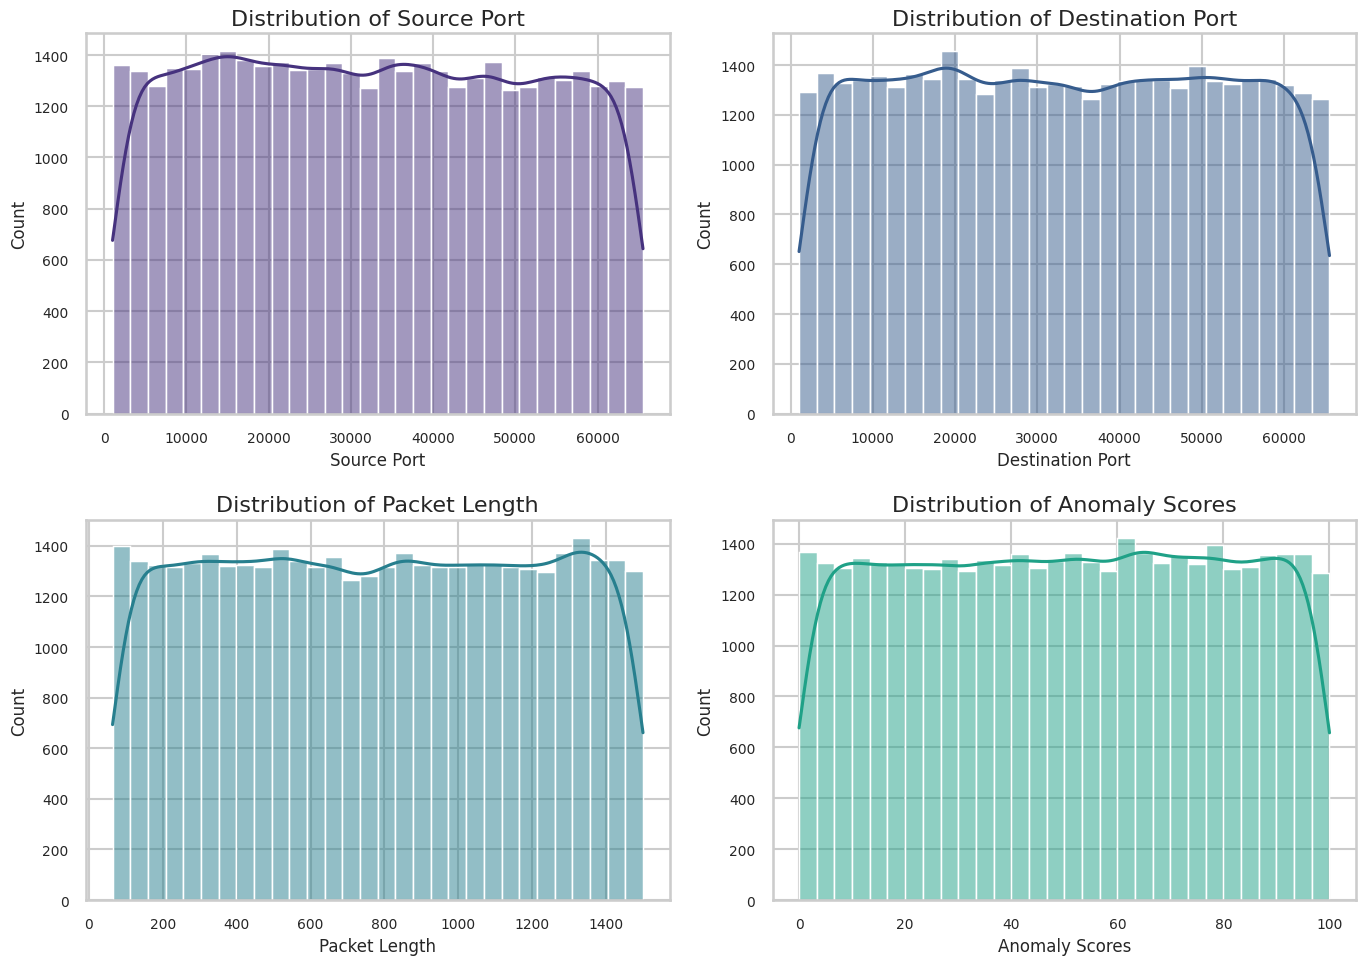

In [12]:

numeric_cols = eda_df.select_dtypes(include=np.number).columns.tolist()
print("Numeric columns:", numeric_cols)

if numeric_cols:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i, col in enumerate(numeric_cols[:4]):
        sns.histplot(data=eda_df, x=col, bins=30, kde=True, ax=axes[i], color=palette_numeric[i])
        axes[i].set_title(f"Distribution of {col}")

    for j in range(len(numeric_cols[:4]), 4):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


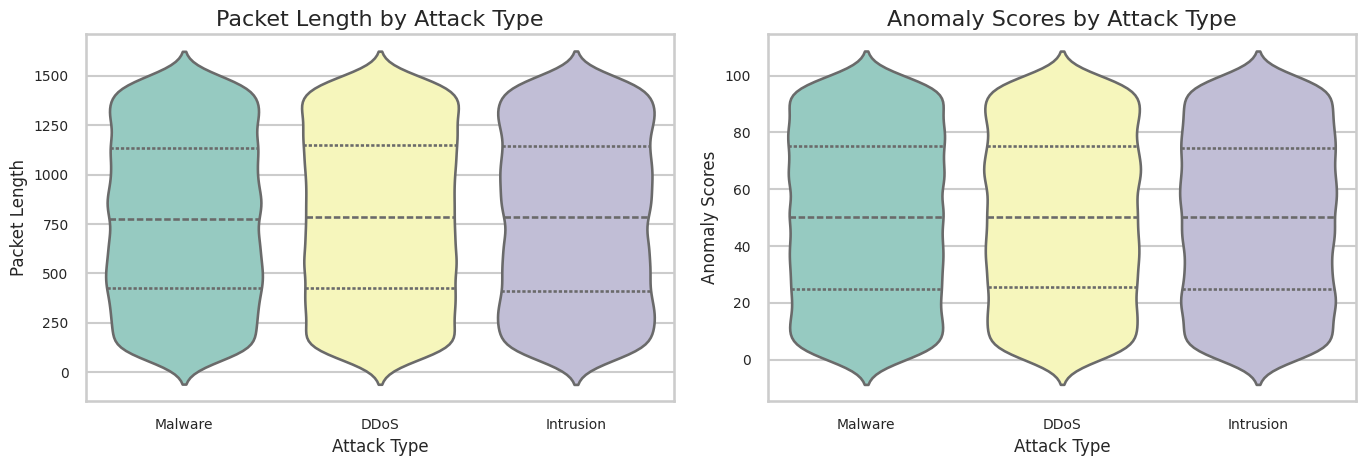

In [13]:

plot_cols = [col for col in ["Packet Length", "Anomaly Scores"] if col in eda_df.columns]

if plot_cols:
    fig, axes = plt.subplots(1, len(plot_cols), figsize=(7 * len(plot_cols), 5), squeeze=False)

    for ax, col in zip(axes[0], plot_cols):
        sns.violinplot(data=eda_df, x=target_col, y=col, palette="Set3", inner="quartile", ax=ax)
        ax.set_title(f"{col} by Attack Type")
        ax.set_xlabel("Attack Type")
        ax.set_ylabel(col)

    plt.tight_layout()
    plt.show()



### Brief interpretation
- Distribution plots show whether the numeric features are tightly clustered, broad, or suspiciously uniform.
- Violin plots are useful because they reveal **class overlap**, which matters when deciding whether simple linear models will be enough.



## Question / Task 10
**Create interaction plots to inspect relationships between numeric variables and between numeric features and classes.**

This helps reveal overlap, separability, and whether non-linear models may be needed.


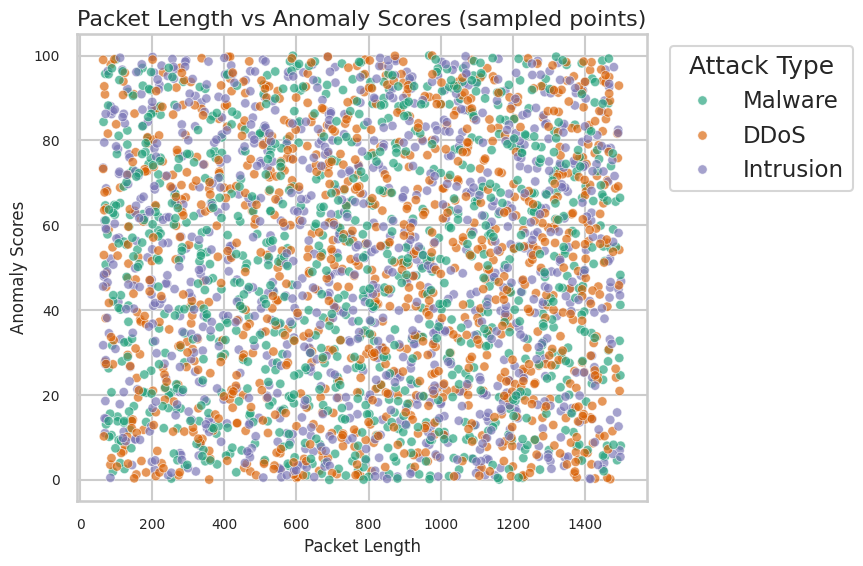

In [14]:

scatter_cols = [col for col in ["Packet Length", "Anomaly Scores"] if col in eda_df.columns]

if len(scatter_cols) == 2:
    sample_scatter = eda_df[[scatter_cols[0], scatter_cols[1], target_col]].dropna().sample(min(3000, len(eda_df)), random_state=42)

    plt.figure(figsize=(9, 6))
    sns.scatterplot(
        data=sample_scatter,
        x=scatter_cols[0],
        y=scatter_cols[1],
        hue=target_col,
        palette="Dark2",
        alpha=0.65,
        s=45
    )
    plt.title(f"{scatter_cols[0]} vs {scatter_cols[1]} (sampled points)")
    plt.xlabel(scatter_cols[0])
    plt.ylabel(scatter_cols[1])
    plt.legend(title=target_col, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


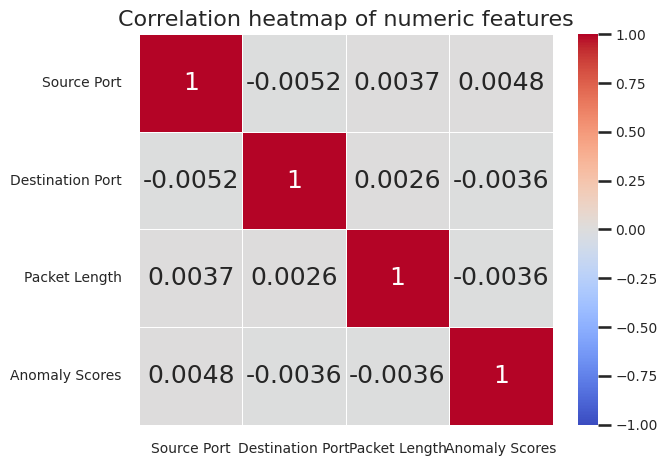

In [15]:

if numeric_cols:
    corr = eda_df[numeric_cols].corr(numeric_only=True)
    plt.figure(figsize=(7, 5))
    sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
    plt.title("Correlation heatmap of numeric features")
    plt.tight_layout()
    plt.show()



### Brief interpretation
- A heavily overlapping scatter plot suggests that the classes may not separate well in only two numeric dimensions.
- The correlation heatmap tells us whether redundancy is strong enough to consider feature dropping or whether each numeric variable may contribute distinct information.



## Question / Task 11
**Inspect temporal structure by plotting attack counts over time.**

If the dataset has meaningful time structure, this matters for train/test splitting and for monitoring concept drift later.


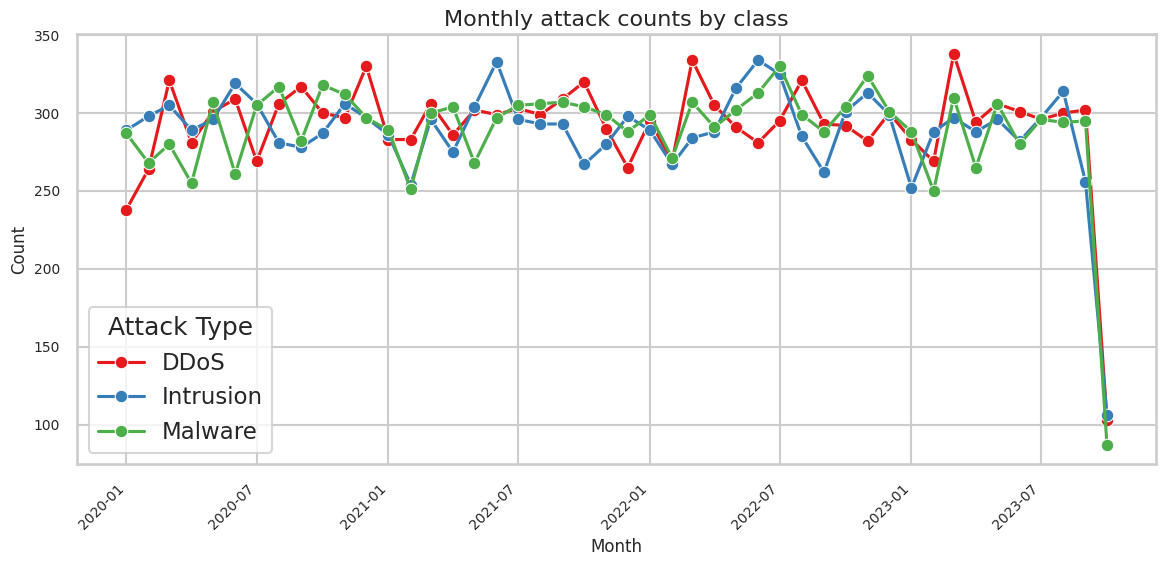

In [16]:

if "Timestamp" in eda_df.columns and pd.api.types.is_datetime64_any_dtype(eda_df["Timestamp"]):
    monthly_counts = (
        eda_df.assign(Month=eda_df["Timestamp"].dt.to_period("M").dt.to_timestamp())
              .groupby(["Month", target_col])
              .size()
              .reset_index(name="Count")
    )

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=monthly_counts, x="Month", y="Count", hue=target_col, palette="Set1", marker="o")
    plt.title("Monthly attack counts by class")
    plt.xlabel("Month")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Timestamp could not be parsed for temporal analysis.")



### Brief interpretation
- Time plots reveal whether the class frequencies are stable or whether some periods look systematically different.
- If future attack data may differ from past attack data, a **time-aware split** can be more realistic than a purely random split.



## Question / Task 12
**Inspect relationships among important categorical variables.**

Here we use a heatmap to study the interaction between protocol and traffic type, which may reveal operational structure in the data.


Traffic Type,DNS,FTP,HTTP
Protocol,,,
ICMP,4513,4386,4530
TCP,4463,4373,4436
UDP,4400,4505,4394


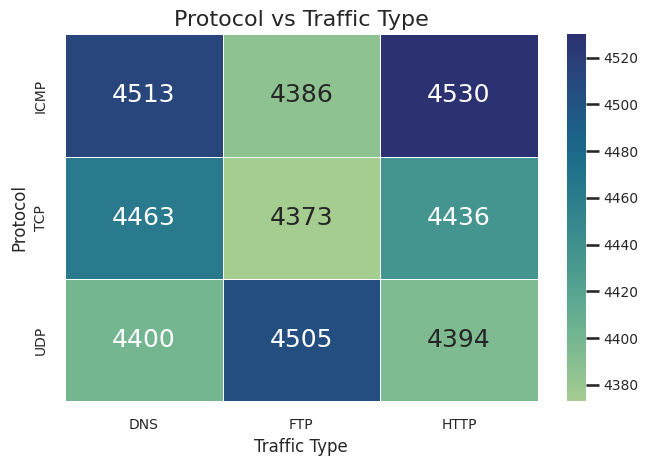

In [17]:

if {"Protocol", "Traffic Type"}.issubset(eda_df.columns):
    proto_traffic = pd.crosstab(eda_df["Protocol"], eda_df["Traffic Type"])
    display(proto_traffic)

    plt.figure(figsize=(7, 5))
    sns.heatmap(proto_traffic, annot=True, fmt="d", cmap="crest", linewidths=0.5)
    plt.title("Protocol vs Traffic Type")
    plt.xlabel("Traffic Type")
    plt.ylabel("Protocol")
    plt.tight_layout()
    plt.show()
else:
    print("Required columns not found for this analysis.")



### Brief interpretation
- This type of cross-tab visualization helps detect whether categories are strongly associated or nearly independent.
- Strong structure here could support feature engineering through interactions, while very uniform patterns may suggest limited extra predictive signal.



## Question / Task 13
**End the EDA section with a short table called `EDA → pipeline implications`.**

The point is to turn exploratory findings into concrete downstream actions for preprocessing, splitting, modeling, and threshold setting.


In [18]:

implications = pd.DataFrame([
    {
        "EDA finding": "Attack Type classes are roughly balanced.",
        "Why it matters": "Severe class imbalance is not the main risk in this dataset.",
        "EDA → pipeline implication": "Use stratified splitting first; strong resampling may not be necessary in the baseline model."
    },
    {
        "EDA finding": "Several columns have about 50% missingness.",
        "Why it matters": "Dropping or imputing these columns blindly may lose useful information or introduce bias.",
        "EDA → pipeline implication": "Test missing-value indicators, compare targeted imputation against feature removal, and document the chosen strategy clearly."
    },
    {
        "EDA finding": "Some fields have extremely high uniqueness ratios.",
        "Why it matters": "Near-identifier variables can overfit badly when encoded naively.",
        "EDA → pipeline implication": "Exclude raw identifiers from baseline models or replace them with engineered summaries, hashing, or embeddings."
    },
    {
        "EDA finding": "Numeric features show broad spread but limited obvious class separation.",
        "Why it matters": "Simple thresholds on one or two numeric columns may not be enough for strong multiclass performance.",
        "EDA → pipeline implication": "Compare interpretable baselines with non-linear models such as tree ensembles, and monitor per-class errors."
    },
    {
        "EDA finding": "Categorical cross-tabs and severity relations appear fairly uniform.",
        "Why it matters": "Single categorical fields may not be highly discriminative on their own.",
        "EDA → pipeline implication": "Rely on combined feature patterns rather than one-field rules, and evaluate interaction-aware models."
    },
    {
        "EDA finding": "The dataset contains a usable timestamp column.",
        "Why it matters": "Security data can drift over time, and random splits may overestimate performance.",
        "EDA → pipeline implication": "Compare random stratified splits with time-aware validation to test robustness against temporal drift."
    },
    {
        "EDA finding": "Operational consequences matter even if classes are balanced.",
        "Why it matters": "False positives and false negatives often carry very different costs in cybersecurity.",
        "EDA → pipeline implication": "Tune decision thresholds using precision-recall trade-offs and business/security cost priorities, not accuracy alone."
    }
])

display(implications)


,EDA finding,Why it matters,EDA → pipeline implication
0,Attack Type classes are roughly balanced.,Severe class imbalance is not the main risk in this dataset.,Use stratified splitting first; strong resampling may not be necessary in the baseline model.
1,Several columns have about 50% missingness.,Dropping or imputing these columns blindly may lose useful information or introduce bias.,"Test missing-value indicators, compare targeted imputation against feature removal, and document..."
2,Some fields have extremely high uniqueness ratios.,Near-identifier variables can overfit badly when encoded naively.,"Exclude raw identifiers from baseline models or replace them with engineered summaries, hashing,..."
3,Numeric features show broad spread but limited obvious class separation.,Simple thresholds on one or two numeric columns may not be enough for strong multiclass performa...,"Compare interpretable baselines with non-linear models such as tree ensembles, and monitor per-c..."
4,Categorical cross-tabs and severity relations appear fairly uniform.,Single categorical fields may not be highly discriminative on their own.,"Rely on combined feature patterns rather than one-field rules, and evaluate interaction-aware mo..."
5,The dataset contains a usable timestamp column.,"Security data can drift over time, and random splits may overestimate performance.",Compare random stratified splits with time-aware validation to test robustness against temporal ...
6,Operational consequences matter even if classes are balanced.,False positives and false negatives often carry very different costs in cybersecurity.,Tune decision thresholds using precision-recall trade-offs and business/security cost priorities...



## Final note

This notebook is intentionally more visual than the earlier version. It keeps the original report structure, but adds more colorful plots and richer diagnostic views so the EDA feels more complete and more presentation-ready.
